In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
from Modules import LookUpFunction as ce

In [42]:
importlib.reload(ce)

<module 'Modules.LookUpFunction' from 'c:\\Users\\moham\\OneDrive\\Desktop\\Data\\Auto Scrapper\\AutoTrader Project\\Project 1\\Modules\\LookUpFunction.py'>

In [43]:
def build_std_deviation_table(df, group_col="Make", value_col="price"):
    """
    For each group in group_col, computes:
        - mean, std of value_col
        - count of rows beyond 1, 2, and 3 standard deviations from the mean
    """
    results = []

    for make, group in df.groupby(group_col):
        mean = group[value_col].mean()
        std = group[value_col].std()

        beyond_1std = (abs(group[value_col] - mean) > 1 * std).sum()
        beyond_2std = (abs(group[value_col] - mean) > 2 * std).sum()
        beyond_3std = (abs(group[value_col] - mean) > 3 * std).sum()

        results.append({
            group_col: make,
            "count": len(group),
            "mean": mean,
            "std": std,
            "beyond_1std": beyond_1std,
            "beyond_2std": beyond_2std,
            "beyond_3std": beyond_3std,
        })

    return pd.DataFrame(results).sort_values("count", ascending=False).reset_index(drop=True)



In [ ]:
df = pd.read_csv("../Data/master.csv.csv")
enriched_Data = pd.read_excel("DataEnrichment/EngineType_enriched.xlsx")
model_flags = pd.read_csv("Model Flag.csv")

In [45]:
df.columns

Index(['scraped_at', 'source_url', 'page', 'url', 'make_model', 'trim',
       'price', 'mileage', 'transmission', 'fuel_type', 'Dealer Name',
       'Dealer Address', 'Dealer URL'],
      dtype='object')

In [46]:
#How Many Duplicate Cars we have:
duplicate_count=df["url"].duplicated().sum()
print(f"Number of duplicate URLs: {duplicate_count}")
df = df.drop_duplicates(subset=["url"],keep="last")

Number of duplicate URLs: 252


<p>There are so many values in price column as Price on Request, about 13% in the initial dataset, I dropped them all.</p>

In [47]:
print(f"In this DataSet We have this many NAN {np.round(df["price"].isna().sum() / df["price"].shape[0]*100)} %")

In this DataSet We have this many NAN 3.0 %


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60591 entries, 0 to 60842
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   scraped_at      60590 non-null  object 
 1   source_url      60590 non-null  object 
 2   page            60590 non-null  float64
 3   url             60590 non-null  object 
 4   make_model      60590 non-null  object 
 5   trim            56060 non-null  object 
 6   price           58627 non-null  object 
 7   mileage         57984 non-null  object 
 8   transmission    57164 non-null  object 
 9   fuel_type       57451 non-null  object 
 10  Dealer Name     24874 non-null  object 
 11  Dealer Address  24874 non-null  object 
 12  Dealer URL      8673 non-null   object 
dtypes: float64(1), object(12)
memory usage: 6.5+ MB


In [49]:
model_flags[["Make","Model","std_tier"]]
#

,Make,Model,std_tier
0,Porsche,Taycan,0std
1,Audi,SQ8,3std
2,BMW,X7,2std
3,Cadillac,Escalade,3std
4,Mercedes-Benz,GLS,2std
...,...,...,...
222,Hyundai,Elantra,0std
223,Kia,K4,0std
224,Hyundai,Venue,0std
225,Hyundai,ELANTRA,0std


In [50]:
Year = pd.DataFrame(columns=["Year","Make","Model"])
df[["Year","Make","Model","MoreInformation"]]=df["make_model"].str.split(" ",expand=True,n=3)
df.head()


,scraped_at,source_url,page,url,make_model,trim,price,mileage,transmission,fuel_type,Dealer Name,Dealer Address,Dealer URL,Year,Make,Model,MoreInformation
0,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/lincoln-corsa...,2022 Lincoln Corsair,NaN,"$27,999","109,941 km",Automatic,Gas,NaN,NaN,NaN,2022,Lincoln,Corsair,None
1,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/jeep-cherokee...,2026 Jeep Cherokee,Laredo,"$47,660",50 km,Automatic,Gas/Electric Hybrid,NaN,NaN,NaN,2026,Jeep,Cherokee,None
2,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/jeep-cherokee...,2026 Jeep Cherokee,LAREDO BlindSpot and CrossPath Detection Drowsy,"$47,198",18 km,Automatic,Gas/Electric Hybrid,NaN,NaN,NaN,2026,Jeep,Cherokee,None
4,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/hyundai-tucso...,2026 Hyundai Tucson,Preferred AWD w/Trend Pkg,"$42,219",150 km,Automatic,Gas,NaN,NaN,NaN,2026,Hyundai,Tucson,None
5,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/mazda-3-sport...,2021 Mazda Mazda3 Sport,SPORT GT | Nav | Leather | Sunroof | BSM | Car...,NaN,"129,000 km",Automatic,Gas,NaN,NaN,NaN,2021,Mazda,Mazda3,Sport


In [51]:
df = df.merge(model_flags[["Make", "Model", "std_tier"]], on=["Make", "Model"], how="left", validate="many_to_one")

df["std_tier"] = df["std_tier"].fillna("Normal")
print(f"Rows before merge: {len(df)}")
# (run the merge)
print(f"Rows after merge: {len(df)}")
print(df["std_tier"].value_counts(dropna=False))

Rows before merge: 60591
Rows after merge: 60591
std_tier
0std      47304
Normal     5900
1std       5689
2std       1313
3std        385
Name: count, dtype: int64


In [52]:
#Price needs to get converted from object to float.
df["price"]=df["price"].str.replace('$',"")
df["price"]=df["price"].str.replace(',',"")
df["price"]=pd.to_numeric(df["price"],errors="coerce")
df.dropna(subset=["price"],inplace=True)
print(f"In this DataSet We have {np.round(df["price"].isna().sum() / df["price"].shape[0]*100)} %")

In this DataSet We have 0.0 %


In [53]:
#I need to convert mileage to float.
df["mileage"]=df["mileage"].str.replace("km","")
df["mileage"]=df["mileage"].str.replace(",","")
condition =df["mileage"].isna() & df["Year"].isin(["2026","2027"])
df.loc[condition,"mileage"] = 0
df.dropna(subset=["mileage"], inplace=True)
df["mileage"]=df["mileage"].astype(float)
df["Year"] = pd.to_numeric(df["Year"],errors="coerce")

In [54]:
#I need to Make condition Columns to have a New and old cars seperated.
condition = df["Year"].isin([ 2025,2026, 2027]) & (df["mileage"] <= 250)
df.loc[condition, "Condition"] = "New"
df.loc[~condition, "Condition"] = "Used"
df.head()

,scraped_at,source_url,page,url,make_model,trim,price,mileage,transmission,fuel_type,Dealer Name,Dealer Address,Dealer URL,Year,Make,Model,MoreInformation,std_tier,Condition
0,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/lincoln-corsa...,2022 Lincoln Corsair,NaN,27999.0,109941.0,Automatic,Gas,NaN,NaN,NaN,2022.0,Lincoln,Corsair,None,0std,Used
1,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/jeep-cherokee...,2026 Jeep Cherokee,Laredo,47660.0,50.0,Automatic,Gas/Electric Hybrid,NaN,NaN,NaN,2026.0,Jeep,Cherokee,None,0std,New
2,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/jeep-cherokee...,2026 Jeep Cherokee,LAREDO BlindSpot and CrossPath Detection Drowsy,47198.0,18.0,Automatic,Gas/Electric Hybrid,NaN,NaN,NaN,2026.0,Jeep,Cherokee,None,0std,New
3,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/hyundai-tucso...,2026 Hyundai Tucson,Preferred AWD w/Trend Pkg,42219.0,150.0,Automatic,Gas,NaN,NaN,NaN,2026.0,Hyundai,Tucson,None,0std,New
5,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/mazda-cx-5-su...,2024 Mazda CX-5,Suna AWD/CLEAN CARFAX/LOW MILEAGE/SERVICE RECORD,36998.0,38480.0,Automatic,Gas,NaN,NaN,NaN,2024.0,Mazda,CX-5,None,0std,Used


In [55]:
df[df["Condition"] == "Used"].shape[0]

30674

In [56]:
# --- Mileage ---
mileage_bins = pd.cut(df["mileage"], bins=range(0, int(df["mileage"].max()) + 100000, 100000))
mileage_counts = mileage_bins.value_counts()

valid_mileage_bins = mileage_counts[mileage_counts >= 100].index
df = df[mileage_bins.isin(valid_mileage_bins)]

price_bins = pd.cut(df["price"], bins=range(0, int(df["price"].max()) + 5000, 5000))
price_counts = price_bins.value_counts()

valid_price_bins = price_counts[price_counts >= 100].index
df = df[price_bins.isin(valid_price_bins)]

In [57]:
#Calculating the Age of Car:
df["Age"] = 2027 - df["Year"]

In [58]:
#Dropping old ass cars I only want the cars who are above 2005
df=df[df["Year"]>=2005]
df=df[(df["fuel_type"] == "Gas") | (df["fuel_type"] == "Gas/Electric Hybrid") | (df["fuel_type"] == "Electric") | (df["fuel_type"] == "Disel")]

In [59]:
def to_str(x):
    if isinstance(x, list):
        return " ".join(str(i) for i in x)
    elif pd.isna(x):
        return ""
    else:
        return str(x)

df["Make"] = df["Make"].apply(to_str)
df["Model"] = df["Model"].apply(to_str)
df["MoreInformation"] = df["MoreInformation"].apply(to_str)

In [60]:
df = df.dropna(subset=["Make", "Model"])
df.head()
df["Combined"] = (df["Make"] + " " + df["Model"] + " " + df["MoreInformation"]).str.strip()
df["Combined"] = df["Combined"].str.replace(r"\s+", " ", regex=True).str.strip()
df

,scraped_at,source_url,page,url,make_model,trim,price,mileage,transmission,fuel_type,...,Dealer Address,Dealer URL,Year,Make,Model,MoreInformation,std_tier,Condition,Age,Combined
0,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/lincoln-corsa...,2022 Lincoln Corsair,NaN,27999.0,109941.0,Automatic,Gas,...,NaN,NaN,2022.0,Lincoln,Corsair,,0std,Used,5.0,Lincoln Corsair
1,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/jeep-cherokee...,2026 Jeep Cherokee,Laredo,47660.0,50.0,Automatic,Gas/Electric Hybrid,...,NaN,NaN,2026.0,Jeep,Cherokee,,0std,New,1.0,Jeep Cherokee
2,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/jeep-cherokee...,2026 Jeep Cherokee,LAREDO BlindSpot and CrossPath Detection Drowsy,47198.0,18.0,Automatic,Gas/Electric Hybrid,...,NaN,NaN,2026.0,Jeep,Cherokee,,0std,New,1.0,Jeep Cherokee
3,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/hyundai-tucso...,2026 Hyundai Tucson,Preferred AWD w/Trend Pkg,42219.0,150.0,Automatic,Gas,...,NaN,NaN,2026.0,Hyundai,Tucson,,0std,New,1.0,Hyundai Tucson
5,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/mazda-cx-5-su...,2024 Mazda CX-5,Suna AWD/CLEAN CARFAX/LOW MILEAGE/SERVICE RECORD,36998.0,38480.0,Automatic,Gas,...,NaN,NaN,2024.0,Mazda,CX-5,,0std,Used,3.0,Mazda CX-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60586,2026-07-27 20:08:20,https://www.autotrader.ca/cars/reg_on/cit_thor...,2.0,https://www.autotrader.ca/offers/ford-escape-t...,2021 Ford Escape Hybrid,Titanium Hybrid AWD |Clean Carfax |One owner,23990.0,35197.0,Automatic,Gas/Electric Hybrid,...,"Mississauga, ON • 33 km from you",NaN,2021.0,Ford,Escape,Hybrid,0std,Used,6.0,Ford Escape Hybrid
60587,2026-07-27 20:08:20,https://www.autotrader.ca/cars/reg_on/cit_thor...,2.0,https://www.autotrader.ca/offers/mercedes-benz...,2021 Mercedes-Benz GLA,GLA35 AMG | 4MATIC | Nav | Panoroof | AmbientL...,30850.0,109000.0,Automatic,Gas,...,"TORONTO, ON • 7 km from you",https://www.autotrader.ca/dealers/47946161,2021.0,Mercedes-Benz,GLA,,0std,Used,6.0,Mercedes-Benz GLA
60588,2026-07-27 20:08:20,https://www.autotrader.ca/cars/reg_on/cit_thor...,2.0,https://www.autotrader.ca/offers/volkswagen-je...,2022 Volkswagen Jetta,HIGHLINE | Nav | Leather | Panoroof | DigitalDash,22450.0,99000.0,Automatic,Gas,...,"TORONTO, ON • 7 km from you",https://www.autotrader.ca/dealers/47946161,2022.0,Volkswagen,Jetta,,0std,Used,5.0,Volkswagen Jetta
60589,2026-07-27 20:08:20,https://www.autotrader.ca/cars/reg_on/cit_thor...,2.0,https://www.autotrader.ca/offers/volkswagen-je...,2024 Volkswagen Jetta GLI,Nav | Leather | Panoroof | Ambient Light | Car...,27850.0,79000.0,Automatic,Gas,...,"TORONTO, ON • 7 km from you",https://www.autotrader.ca/dealers/47946161,2024.0,Volkswagen,Jetta,GLI,0std,Used,3.0,Volkswagen Jetta GLI


In [61]:
unspecific_values = ["Other", "Unknown", "N/A", "Unspecified"]  # adjust based on what you actually see

df = df[~df["Make"].isin(unspecific_values)]
df = df[~df["Model"].isin(unspecific_values)]

In [62]:
df = ce.enrich_dataframe(df)

In [63]:
df

,scraped_at,source_url,page,url,make_model,trim,price,mileage,transmission,fuel_type,...,no_accidents,has_carfax,one_owner,low_mileage_mention,service_records,certified,Engine_Description,Package_Description,Country_of_Origin,Brand_Segment
0,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/lincoln-corsa...,2022 Lincoln Corsair,NaN,27999.0,109941.0,Automatic,Gas,...,0,0,0,0,0,0,None,None,USA,Luxury
1,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/jeep-cherokee...,2026 Jeep Cherokee,Laredo,47660.0,50.0,Automatic,Gas/Electric Hybrid,...,0,0,0,0,0,0,None,None,USA,Mainstream
2,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/jeep-cherokee...,2026 Jeep Cherokee,LAREDO BlindSpot and CrossPath Detection Drowsy,47198.0,18.0,Automatic,Gas/Electric Hybrid,...,0,0,0,0,0,0,None,None,USA,Mainstream
3,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/hyundai-tucso...,2026 Hyundai Tucson,Preferred AWD w/Trend Pkg,42219.0,150.0,Automatic,Gas,...,0,0,0,0,0,0,None,Preferred,South Korea,Economy
5,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/mazda-cx-5-su...,2024 Mazda CX-5,Suna AWD/CLEAN CARFAX/LOW MILEAGE/SERVICE RECORD,36998.0,38480.0,Automatic,Gas,...,0,1,0,1,1,0,None,None,Japan,Mainstream
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60586,2026-07-27 20:08:20,https://www.autotrader.ca/cars/reg_on/cit_thor...,2.0,https://www.autotrader.ca/offers/ford-escape-t...,2021 Ford Escape Hybrid,Titanium Hybrid AWD |Clean Carfax |One owner,23990.0,35197.0,Automatic,Gas/Electric Hybrid,...,0,1,1,0,0,0,Hybrid,None,USA,Mainstream
60587,2026-07-27 20:08:20,https://www.autotrader.ca/cars/reg_on/cit_thor...,2.0,https://www.autotrader.ca/offers/mercedes-benz...,2021 Mercedes-Benz GLA,GLA35 AMG | 4MATIC | Nav | Panoroof | AmbientL...,30850.0,109000.0,Automatic,Gas,...,0,0,0,0,0,0,"4MATIC, AMG",None,Germany,Luxury
60588,2026-07-27 20:08:20,https://www.autotrader.ca/cars/reg_on/cit_thor...,2.0,https://www.autotrader.ca/offers/volkswagen-je...,2022 Volkswagen Jetta,HIGHLINE | Nav | Leather | Panoroof | DigitalDash,22450.0,99000.0,Automatic,Gas,...,0,0,0,0,0,0,None,Highline,Germany,Mainstream
60589,2026-07-27 20:08:20,https://www.autotrader.ca/cars/reg_on/cit_thor...,2.0,https://www.autotrader.ca/offers/volkswagen-je...,2024 Volkswagen Jetta GLI,Nav | Leather | Panoroof | Ambient Light | Car...,27850.0,79000.0,Automatic,Gas,...,0,0,0,0,0,0,None,None,Germany,Mainstream


In [64]:
enriched_Data.head()

,fuel_type,Year,Make,Model,MoreInformation,Engine_Description,Body Type,Cylinders,Confidence,Notes
0,Gas,2022,Lincoln,Corsair,NaN,NaN,SUV,4,Medium,NaN
1,Gas/Electric Hybrid,2026,Jeep,Cherokee,NaN,NaN,SUV,4,Medium,NaN
2,Gas,2026,Hyundai,Tucson,NaN,NaN,SUV,4,Medium,NaN
3,Gas,2024,Mazda,CX-5,NaN,NaN,SUV,4,Medium,NaN
4,Gas,2021,Ford,F-150,NaN,NaN,Pickup Truck,6,Medium,NaN


In [65]:
merge_keys = ["fuel_type", "Year", "Make", "Model"]  # or whatever keys you're using
enriched_Data = enriched_Data.drop_duplicates(subset=merge_keys, keep="first")
df = df.merge(enriched_Data, on=merge_keys, how="left", validate="many_to_one")
print(len(df), "->", len(enriched_Data))

42016 -> 3933


In [66]:
df.loc[df["fuel_type"] == "Electric", "Cylinders"] = "Electric"
df["Cylinders"] = df["Cylinders"].astype("category")

In [67]:
make_counts = df["Make"].value_counts()

valid_makes = make_counts[make_counts >= 100].index

df = df[df["Make"].isin(valid_makes)]

In [68]:
df.head()

,scraped_at,source_url,page,url,make_model,trim,price,mileage,transmission,fuel_type,...,Engine_Description_x,Package_Description,Country_of_Origin,Brand_Segment,MoreInformation_y,Engine_Description_y,Body Type,Cylinders,Confidence,Notes
0,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/lincoln-corsa...,2022 Lincoln Corsair,NaN,27999.0,109941.0,Automatic,Gas,...,None,None,USA,Luxury,NaN,NaN,SUV,4,Medium,NaN
1,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/jeep-cherokee...,2026 Jeep Cherokee,Laredo,47660.0,50.0,Automatic,Gas/Electric Hybrid,...,None,None,USA,Mainstream,NaN,NaN,SUV,4,Medium,NaN
2,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/jeep-cherokee...,2026 Jeep Cherokee,LAREDO BlindSpot and CrossPath Detection Drowsy,47198.0,18.0,Automatic,Gas/Electric Hybrid,...,None,None,USA,Mainstream,NaN,NaN,SUV,4,Medium,NaN
3,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/hyundai-tucso...,2026 Hyundai Tucson,Preferred AWD w/Trend Pkg,42219.0,150.0,Automatic,Gas,...,None,Preferred,South Korea,Economy,NaN,NaN,SUV,4,Medium,NaN
4,2026-05-20 16:34,https://www.autotrader.ca/cars/on/toronto/,1.0,https://www.autotrader.ca/offers/mazda-cx-5-su...,2024 Mazda CX-5,Suna AWD/CLEAN CARFAX/LOW MILEAGE/SERVICE RECORD,36998.0,38480.0,Automatic,Gas,...,None,None,Japan,Mainstream,NaN,NaN,SUV,4,Medium,NaN


In [69]:
#dropping the columns that I won't use for Now:
df.drop(columns=["scraped_at","source_url","url","page","Dealer Name","Dealer Address","Dealer URL","low_mileage_mention","MoreInformation_y"],inplace=True)

In [70]:
df.to_csv("PreEDAVersion.csv")

In [71]:
#I need two diffrenet Models one for Regression Models the other one for Tree based Models But both of the models have something similar to each other.
df.columns

Index(['make_model', 'trim', 'price', 'mileage', 'transmission', 'fuel_type',
       'Year', 'Make', 'Model', 'MoreInformation_x', 'std_tier', 'Condition',
       'Age', 'Combined', 'no_accidents', 'has_carfax', 'one_owner',
       'service_records', 'certified', 'Engine_Description_x',
       'Package_Description', 'Country_of_Origin', 'Brand_Segment',
       'Engine_Description_y', 'Body Type', 'Cylinders', 'Confidence',
       'Notes'],
      dtype='object')

In [72]:
df["Is_Hybrid"]=(df["fuel_type"] == "Gas/Electric Hybrid").astype(int)
df=df.drop(columns=["fuel_type"])

In [73]:
#TreeBaseModel:
TreeModel=df[["Make","Model","MoreInformation_x","Year","price","mileage","transmission","Condition","Age","no_accidents","has_carfax","one_owner","service_records","certified","Is_Hybrid","Country_of_Origin","Body Type","Cylinders","Brand_Segment","std_tier"]]
TreeModel.columns

Index(['Make', 'Model', 'MoreInformation_x', 'Year', 'price', 'mileage',
       'transmission', 'Condition', 'Age', 'no_accidents', 'has_carfax',
       'one_owner', 'service_records', 'certified', 'Is_Hybrid',
       'Country_of_Origin', 'Body Type', 'Cylinders', 'Brand_Segment',
       'std_tier'],
      dtype='object')

In [74]:
TreeModel.to_csv("ModelInput/TreeInput.csv")

In [75]:
#Eda for New Car
NewCars=df[df["Condition"] =="New"]

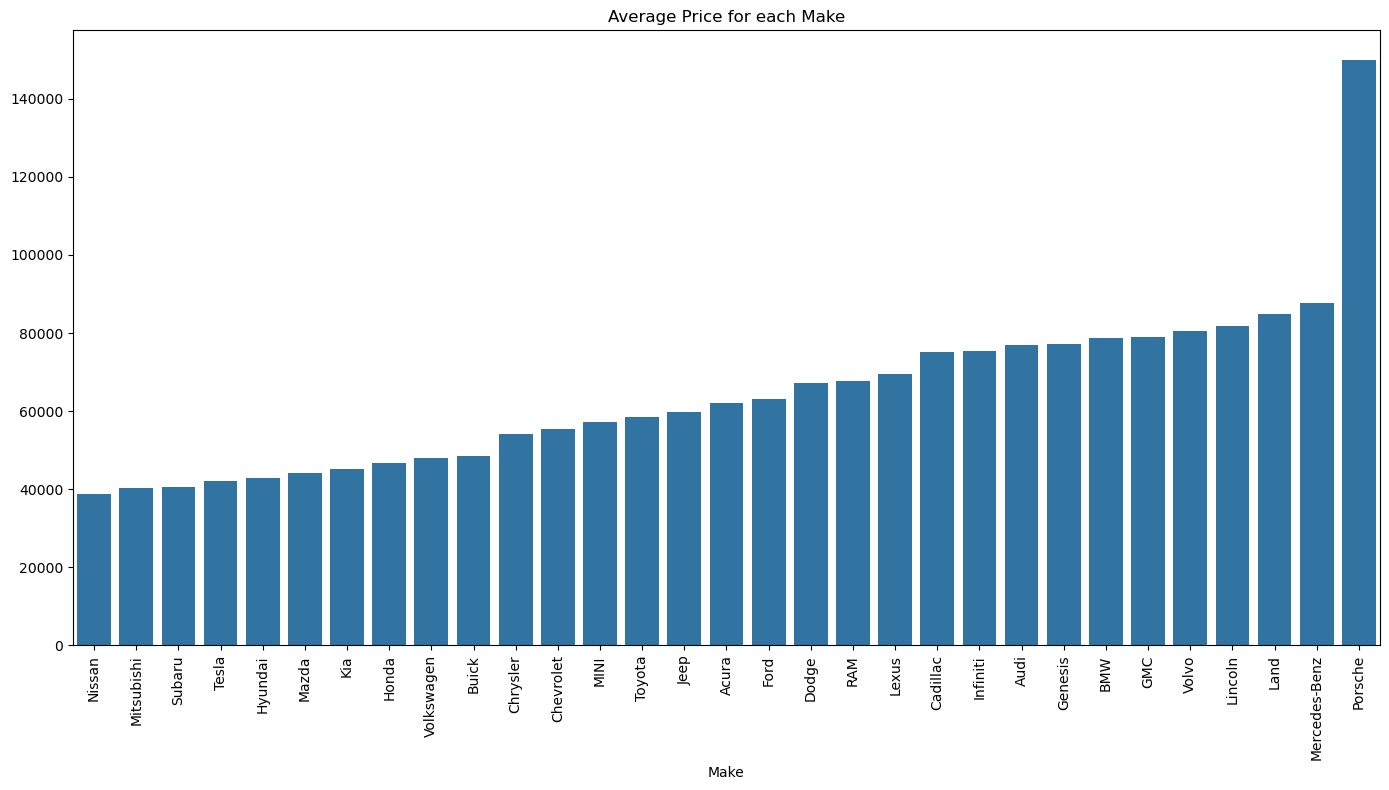

In [76]:
AveragePerMake = NewCars.groupby(["Make"])['price'].mean().sort_values()
x=AveragePerMake.index
y= AveragePerMake.values
plt.figure(figsize=(14,8))
sns.barplot(x=x,y=y)

plt.xticks(rotation=90)
plt.title ("Average Price for each Make")
plt.tight_layout()
plt.show()

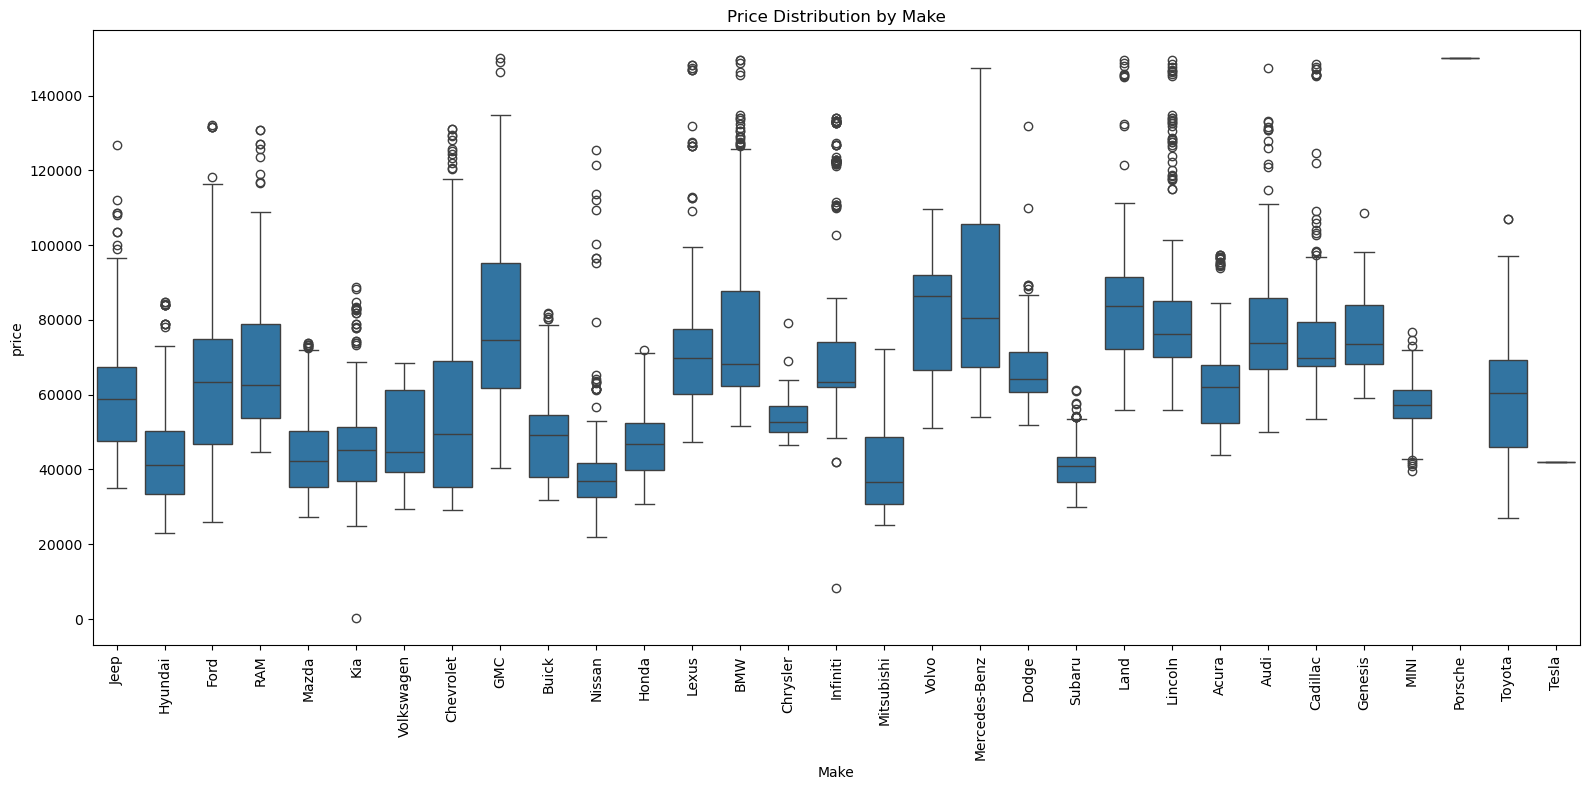

In [77]:
#NewCars[NewCars["Make"] == "BMW"]["price"].mean()

plt.figure(figsize=(16, 8))
sns.boxplot(NewCars, x="Make", y="price")
plt.xticks(rotation=90)
plt.title("Price Distribution by Make")
plt.tight_layout()
plt.show()

In [78]:
NewCars[NewCars['Make'] == ""].groupby("Model")["price"].mean()

Series([], Name: price, dtype: float64)

In [79]:
def build_model_deviation_table(df, make_col="Make", model_col="Model", value_col="price"):
    """
    For each Make: computes the Make's overall mean/std of value_col,
    then checks each Model's AVERAGE value_col against that Make's mean/std,
    counting how many distinct Models fall beyond 1, 2, and 3 standard
    deviations away.
    """
    results = []

    for make, group in df.groupby(make_col):
        make_mean = group[value_col].mean()
        make_std = group[value_col].std()

        # average price per Model within this Make
        model_avgs = group.groupby(model_col)[value_col].mean()

        beyond_1std = ((model_avgs - make_mean) > 1 * make_std).sum()
        beyond_2std = ((model_avgs - make_mean) > 2 * make_std).sum()
        beyond_3std = ((model_avgs - make_mean) > 3 * make_std).sum()

        results.append({
            make_col: make,
            "num_models": model_avgs.shape[0],
            "make_mean": make_mean,
            "make_std": make_std,
            "models_beyond_1std": beyond_1std,
            "models_beyond_2std": beyond_2std,
            "models_beyond_3std": beyond_3std,
        })

    return pd.DataFrame(results).sort_values("num_models", ascending=False).reset_index(drop=True)
model_dev_table = build_model_deviation_table(NewCars, make_col="Make", model_col="Model", value_col="price")
model_dev_table

,Make,num_models,make_mean,make_std,models_beyond_1std,models_beyond_2std,models_beyond_3std
0,BMW,17,78774.093373,23775.854973,8,3,0
1,Toyota,16,58530.247002,17954.767536,2,0,0
2,Audi,15,76978.651316,15407.699515,6,4,2
3,Mercedes-Benz,14,87594.037815,24097.570462,6,1,0
4,Ford,14,63227.588492,17162.123199,4,1,0
5,Chevrolet,12,55460.770942,23294.394505,3,3,0
6,Hyundai,11,42982.184652,12597.664459,2,1,0
7,Kia,11,45066.599004,11121.757444,2,1,0
8,Nissan,11,38779.057613,9725.204470,6,4,2
9,Cadillac,10,75255.224189,15744.365344,2,1,1


In [80]:

def build_model_std_flags(df, make_col="Make", model_col="Model", value_col="price"):
    """
    Returns one row per Make/Model combination with:
        - the model's average value_col
        - a single 'std_tier' column showing the HIGHEST threshold
          that model's average clears (None, "1std", "2std", or "3std")
    """
    results = []

    for make, group in df.groupby(make_col):
        make_mean = group[value_col].mean()
        make_std = group[value_col].std()

        model_avgs = group.groupby(model_col)[value_col].mean()

        for model, avg_price in model_avgs.items():
            if avg_price > make_mean + 3 * make_std:
                tier = "3std"
            elif avg_price > make_mean + 2 * make_std:
                tier = "2std"
            elif avg_price > make_mean + 1 * make_std:
                tier = "1std"
            else:
                tier = "0std"

            results.append({
                make_col: make,
                model_col: model,
                "model_avg_price": avg_price,
                "std_tier": tier,
            })

    return pd.DataFrame(results).sort_values("model_avg_price", ascending=False).reset_index(drop=True)


model_flags = build_model_std_flags(NewCars, make_col="Make", model_col="Model", value_col="price")
model_flags.to_csv("Model Flag.csv")